<a href="https://colab.research.google.com/github/Tuchobm/Curso-IA-Google-Colab/blob/main/2_2_regresor_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Ejercicio 2: Exploración de datos

En este ejercicio, trabajarás con un conjunto de datos de diabetes. Tu tarea es explorar el conjunto de datos y realizar algunas transformaciones básicas. El conjunto de datos contiene información sobre pacientes con diabetes, incluyendo características como edad, sexo, índice de masa corporal (BMI), presión arterial y varios marcadores de colesterol y glucosa en sangre. El objetivo es predecir la progresión de la diabetes en un año.

Además, encontrarás partes del código contendrán  el comentario de `# ACTIVIDAD` que indican dónde debes completar el código o realizar tareas específicas. Asegúrate de seguir las instrucciones y completar el código donde se indique. Finalmente, en el final de este ejercicio, deberás responder a una serie de preguntas.

## Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
from sklearn.datasets import load_diabetes
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
# Aseguramos que los resultados sean reproducibles
np.random.seed(0)

# Informamos a sklearn que queremos que los resultados se muestren como pandas DataFrames
set_config(transform_output="pandas")

# Carga de datos

Haz doble clic aquí para ver la pista de la actividad a continuación.
<!-- Puedes basarte en el código del ejercicio anterior para explorar el conjunto de datos. -->

In [ ]:
data = load_diabetes(scaled=False)
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# ACTIVIDAD: Explorar los datos de entrenamiento
print(df.iloc[5:10])

print(df.describe())

print(df.info())

    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6  target
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0   151.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0    75.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0   141.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0   206.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0   135.0
              age         sex         bmi          bp          s1          s2  \
count  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000   
mean    48.518100    1.468326   26.375792   94.647014  189.140271  115.439140   
std     13.109028    0.499561    4.418122   13.831283   34.608052   30.413081   
min     19.000000    1.000000   18.000000   62.000000   97.000000   41.600000   
25%     38.250000    1.000000   23.200000   84.000000  164.250000   96.050000   
50%     50.000000    1.000000   25.700000   93.000000  186.000000  113.00000

# Visualización de datos

El primer grafico muestra la correlación entre las características del dataset Iris. La correlación es una medida estadística que indica la relación entre dos variables. En este caso, estamos interesados en la relación entre las características de diabetes.

El segundo gráfico muestra la cantidad de muestras de cada especie que hay en función de cada una de las características. En este caso, estamos utilizando un gráfico de densidad para visualizar la distribución de las características.

Haz doble clic aquí para ver la pista de la actividad a continuación.
<!-- Es la mismas funciones que en el ejercicio anterior, pero en este caso se utiliza el dataset de diabetes. -->

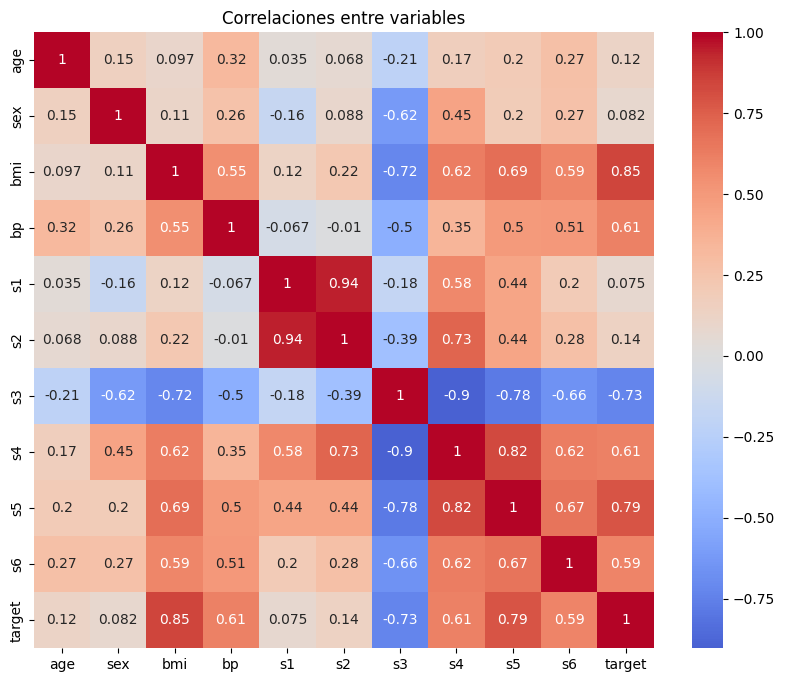

In [ ]:
# ACTIVIDAD: Crear un gráfico de correlaciones entre las variables
correlation = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlaciones entre variables")
plt.show()

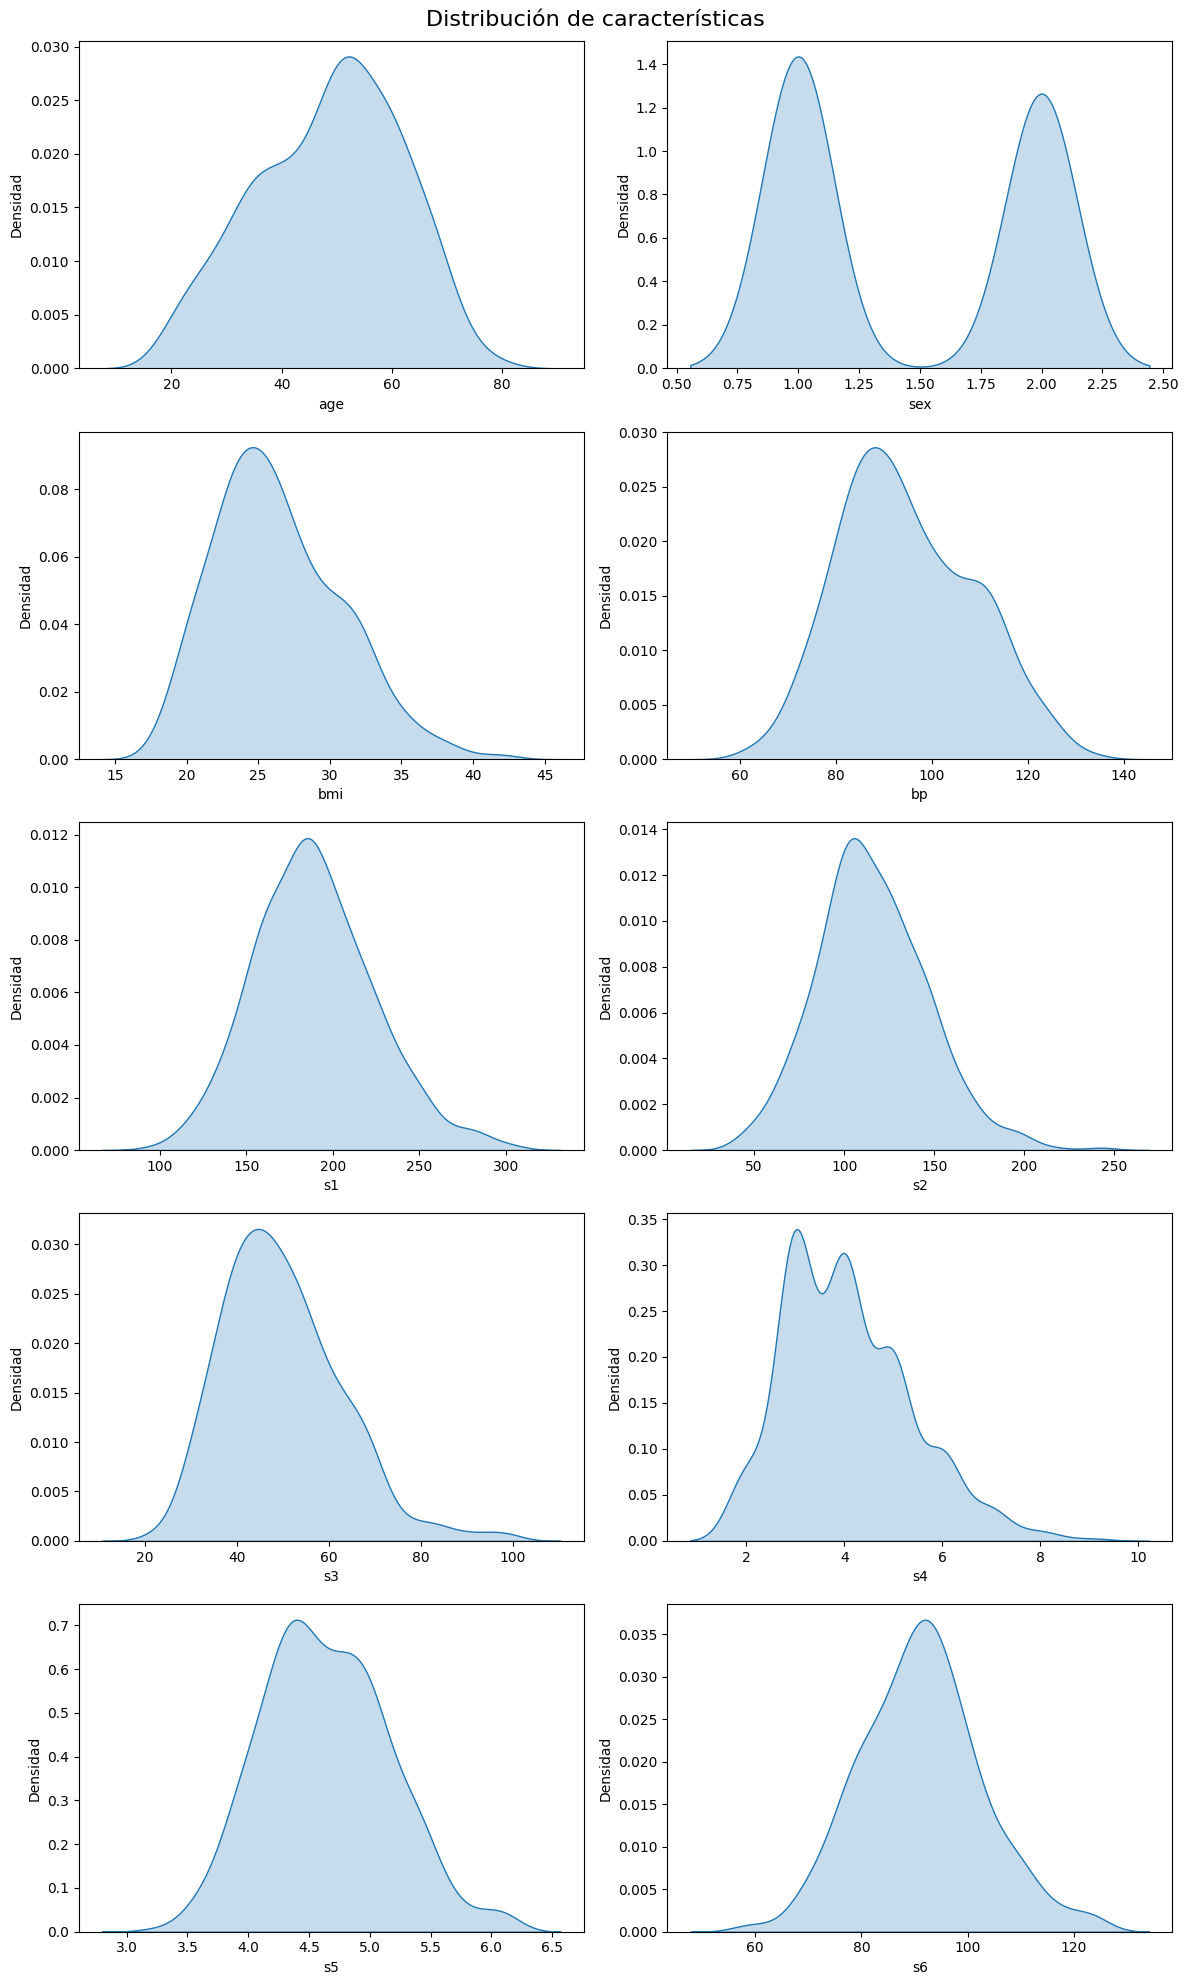

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(12, 20))
for ax, feature in zip(axes.flatten(), df.columns[:-1]):
    sns.kdeplot(data=df, x=feature, ax=ax, fill=True)
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidad")
fig.suptitle("Distribución de características", fontsize=16, y=0.99)
plt.tight_layout()
plt.show()

# Ingeniería de características

Algunas ideas para la ingeniería de características que podrías considerar son:
- Normalización de datos
- Transformación de variables categóricas
- Creación de nuevas variables
- Manejo de datos faltantes o anómalos
- Reducción de dimensionalidad
- Escalado de datos

In [ ]:
# Separar los datos en entrenamiento y prueba
entrenamiento, prueba = train_test_split(df, test_size=0.2, random_state=0)
entrenamiento = entrenamiento.reset_index(drop=True)
prueba = prueba.reset_index(drop=True)

In [ ]:
# ACTIVIDAD: Separa los datos de entrenamiento en entrenamiento y validación (test_size=0.2)
entrenamiento, validacion = train_test_split(
    entrenamiento, test_size=0.2, random_state=0
)

In [ ]:
# # ACTIVIDAD: Prueba de modificar el dataframe para mejorar la predicción
# scaler = StandardScaler()


# def prepare_data(features, is_train=False):
#     # Ejemplo añadiendo una nueva columna
#     features["new_feature"] = features["bmi"] * features["age"]

#     # Añadir una nueva columna
#     features["age_group"] = pd.cut(
#         features["age"],
#         bins=[0, 30, 50, 70, 90],
#         labels=["young", "middle_aged", "old", "very_old"],
#     )

#     # Convertir la nueva columna categórica a variables dummy
#     features = pd.get_dummies(features, columns=["age_group"])

#     # Eliminar columnas no necesarias
#     features.drop(columns=["age"], inplace=True)

#     # Normalizar los datos
#     if is_train:
#         features = scaler.fit_transform(features)
#     else:
#         features = scaler.transform(features)
#     return features


# y_train = entrenamiento["target"]
# entrenamiento = prepare_data(entrenamiento.drop(columns=["target"]), is_train=True)
# entrenamiento["target"] = y_train

# y_validacion = validacion["target"]
# validacion = prepare_data(validacion.drop(columns=["target"]))
# validacion["target"] = y_validacion

# y_prueba = prueba["target"]
# prueba = prepare_data(prueba.drop(columns=["target"]))
# prueba["target"] = y_prueba

In [ ]:
# ACTIVIDAD: Prueba de modificar el dataframe para mejorar la predicción
def add_bmi_age_product(X):
    X["bmi_age_product"] = X["bmi"] * X["age"]
    return X


def add_age_category(X):
    X["age_group"] = pd.cut(
        X["age"],
        bins=[0, 30, 50, 70, 90],
        labels=["young", "middle_aged", "old", "very_old"],
    )
    X = pd.get_dummies(X, columns=["age_group"])
    return X


def drop_columns(X):
    return X.drop(columns=["age"])


# Build pipeline
pipe = Pipeline(
    [
        (
            "add_bmi_age_product",
            FunctionTransformer(add_bmi_age_product),
        ),
        ("add_age_category", FunctionTransformer(add_age_category)),
        ("drop_columns", FunctionTransformer(drop_columns)),
        ("scaler", StandardScaler()),
    ]
)

y_train = entrenamiento.pop("target")
# entrenamiento = pipe.fit_transform(entrenamiento)
entrenamiento["target"] = y_train

y_val = validacion.pop("target")
# validacion = pipe.transform(validacion)
validacion["target"] = y_val

y_test = prueba.pop("target")
# prueba = pipe.transform(prueba)
prueba["target"] = y_test

# Entrenamiento

Prueba de entrenart los modelos mencionados en las presentaciones y encuentra cuál es el mejor modelo para este conjunto de datos. Puedes usar técnicas como:
- LinearRegression
- SVR
- DecisionTreeRegressor
- RandomForestRegressor
- AdaBoostRegressor
- KNeighborsRegressor

In [ ]:
def train(model):
    """Entrena el modelo con los datos de entrenamiento."""
    X_train = entrenamiento.drop(columns=["target"])
    y_train = entrenamiento["target"]

    model.fit(X_train, y_train)
    print("Modelo entrenado.")

    rmse_train = root_mean_squared_error(y_train, model.predict(X_train))
    print(f"RMSE entrenamiento: {rmse_train:.2f}")

    rmse_val = root_mean_squared_error(
        validacion["target"], model.predict(validacion.drop(columns=["target"]))
    )
    print(f"RMSE validación: {rmse_val:.2f}")

In [ ]:
# ACTIVIDAD: Probar diferentes modelos de clasificación
models = {
    "Regresión Lineal": LinearRegression(),
    "SVR": SVR(),
    "Árbol de Decisión": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "KNN": KNeighborsRegressor(),
}

# ACTIVIDAD (AVANZADO): Probar diferentes hiperparámetros para cada model

In [ ]:
# evaluate(model, prueba)
for name, model in models.items():
    print(f"**{name}**")
    model.fit(entrenamiento.drop(columns=["target"]), entrenamiento["target"])
    rmse_val = root_mean_squared_error(
        validacion["target"], model.predict(validacion.drop(columns=["target"]))
    )
    print(f"* RMSE validación (con características): {rmse_val:.2f}")
    rmse_test = root_mean_squared_error(
        prueba["target"], model.predict(prueba.drop(columns=["target"]))
    )
    print(f"* RMSE test (con características): {rmse_test:.2f}")

**Regresión Lineal**
* RMSE validación (con características): 53.20
* RMSE test (con características): 58.15
**SVR**
* RMSE validación (con características): 80.19
* RMSE test (con características): 69.12
**Árbol de Decisión**
* RMSE validación (con características): 79.72
* RMSE test (con características): 81.74
**Random Forest**
* RMSE validación (con características): 61.13
* RMSE test (con características): 56.40
**AdaBoost**
* RMSE validación (con características): 61.06
* RMSE test (con características): 56.28
**KNN**
* RMSE validación (con características): 65.08
* RMSE test (con características): 67.36


In [ ]:
# Pregunta 1: Entrenar un modelo de regresión lineal con una sola característica
for feature in entrenamiento.columns:
    if feature == "target":
        continue
    model = LinearRegression()
    X_train = entrenamiento[[feature]]
    y_train = entrenamiento["target"]
    model.fit(X_train, y_train)
    print(f"**{feature}**")
    rmse_train = root_mean_squared_error(y_train, model.predict(X_train))

    rmse_val = root_mean_squared_error(
        validacion["target"], model.predict(validacion[[feature]])
    )
    print(f"* RMSE validación: {rmse_val:.2f}\n")

**sex**
* RMSE validación: 82.45

**bmi**
* RMSE validación: 57.33

**bp**
* RMSE validación: 81.20

**s1**
* RMSE validación: 80.37

**s2**
* RMSE validación: 81.78

**s3**
* RMSE validación: 71.89

**s4**
* RMSE validación: 72.38

**s5**
* RMSE validación: 64.36

**s6**
* RMSE validación: 76.56

**bmi_age_product**
* RMSE validación: 73.50

**age_group_young**
* RMSE validación: 81.56

**age_group_middle_aged**
* RMSE validación: 82.51

**age_group_old**
* RMSE validación: 81.55

**age_group_very_old**
* RMSE validación: 82.63



# Preguntas

- ¿Cuáles son las características más importantes para predecir la progresión de la diabetes? Prueba de eliminar todas las características menos una y ver el impacto en el rendimiento del Linear Regression. (Sin hacer la ingeniería de características).

  **age**
    * RMSE validación: 73.89

  **sex**
    * RMSE validación: 76.04

  **bmi**
    * RMSE validación: 61.11

  **bp**
    * RMSE validación: 65.65

  **s1**
    * RMSE validación: 73.11

  **s2**
    * RMSE validación: 73.73

  **s3**
    * RMSE validación: 70.08

  **s4**
    * RMSE validación: 66.38

  **s5**
    * RMSE validación: 66.52

  **s6**
    * RMSE validación: 72.13

- ¿Qué técnicas de ingeniería de características fueron más efectivas? (prueba 3 técnicas diferentes y compara los resultados).

  **Regresión Lineal**
    * RMSE validación (sin ingeniería de características): 53.37
    * RMSE validación (con ingeniería de características): 53.03

  **SVR**
    * RMSE validación (sin ingeniería de características): 79.63
    * RMSE validación (con ingeniería de características): 74.60

  **Árbol de Decisión**
    * RMSE validación (sin ingeniería de características): 62.09
    * RMSE validación (con ingeniería de características): 64.53

  **Random Forest**
    * RMSE validación (sin ingeniería de características): 56.44
    * RMSE validación (con ingeniería de características): 57.37

  **AdaBoost**
    * RMSE validación (sin ingeniería de características): 57.69
    * RMSE validación (con ingeniería de características): 55.76

  **KNN**
    * RMSE validación (sin ingeniería de características): 69.79
    * RMSE validación (con ingeniería de características): 61.53

- ¿Hubo alguna sorpresa en los resultados y por qué crees que ocurrió?
    * La regresión lineal fue el modelo que mejor se desempeñó en general incluso en comparación a otros modelos más complejos. Esto puedes ser debido a que los otros modelos están haciendo overfitting a los datos de entrenamiento y no generalizan bien a los datos de validación. Por otro lado, la regresión lineal es un modelo muy simple y no tiende a hacer overfitting, por lo que es más probable que generalice mejor a los datos de validación.
  
- ¿Hay alguna diferencia significativa con los resultados en el dataset de validación y el de test?
    * En general no, el orden de los resultados es el mismo. Sin embargo, el modelo de Decision Tree tuvo un desempeño mucho peor en el dataset de test, lo que puede ser un indicativo de que este modelo está haciendo overfitting a los datos de entrenamiento y no generaliza bien.

- ¿Qué modelo observas que se ve más afectado por las características que no son relevantes? ¿Por qué?
    * KNN es el modelo que se ve más afectado por las características que no son relevantes. Esto puede ser debido a que KNN es un modelo basado en la distancia, y si hay características que no son relevantes, pueden afectar la distancia entre los puntos y por lo tanto afectar el rendimiento del modelo.